## importing library

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## taking the dataset

In [39]:
df=pd.read_csv('../Data/height-weight.csv')

In [40]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


## using scatter plot

Text(0, 0.5, 'Height')

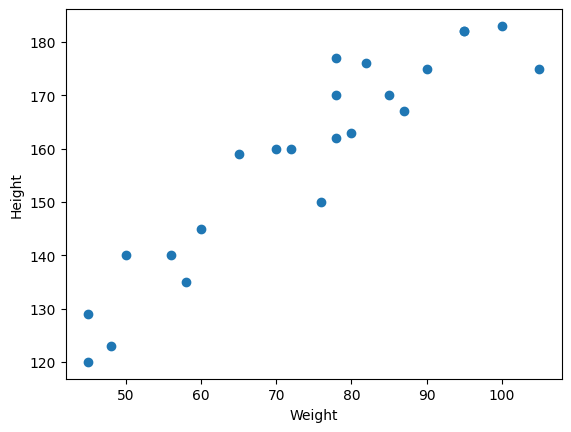

In [41]:
## scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

##it used to visualize the height and weight in the 
##graphical way or in x and y axis

## using seaborn 

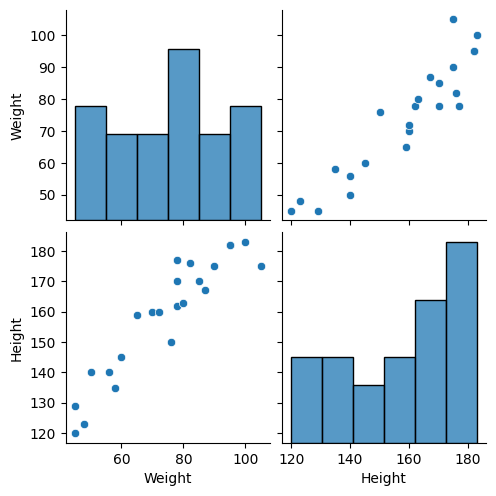

In [42]:
## seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [43]:
X= df[['Weight']]
## the independent feature should be in 2D array
X

Y= df['Height']
## the dependent feature sould be in 1D array
Y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

## train_test_split

In [44]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.2,random_state=42)

## using standardization

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_train

X_test  = scaler.transform(X_test)
X_test


array([[ 0.21043706],
       [ 0.21043706],
       [-1.6552288 ],
       [ 1.17153765],
       [-0.52452222]])

## linear regression

In [46]:
from sklearn.linear_model import LinearRegression
regression= LinearRegression(n_jobs=-1)
regression.fit(X_train,Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
print('coefficient or slope: ', regression.coef_)
print('intercept: ',regression.intercept_)

coefficient or slope:  [17.03440872]
intercept:  157.5


## plot best fit line

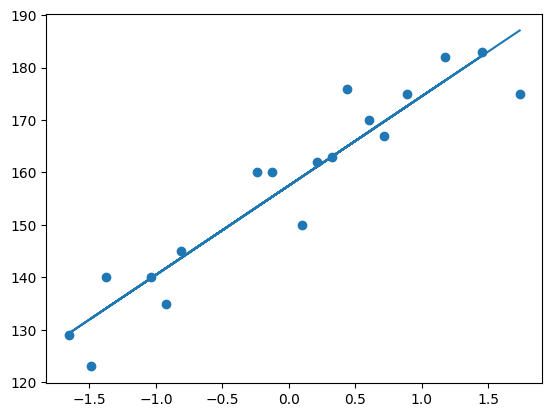

In [48]:
  plt.scatter(X_train, Y_train)
  plt.plot(X_train, regression.predict(X_train))

## prdiction of the test data

In [49]:
y_pred = regression.predict(X_test)

## performence metrics

In [50]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [51]:
mse= mean_squared_error(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
rmse = np.sqrt(mse)
score = r2_score(Y_test,y_pred)
print(mse)
print(mae)
print(rmse)
print(score)

109.77592599051664
9.822657814519232
10.477400726827081
0.776986986042344


## prediction for new data

In [ ]:
regression.predict(scaler.transform([[72]]))

## you have to write scaler.transfrom because 
#  the model is trained on scaled data so you have to scale 
#  the input data as well before prediction

/Users/ali/Desktop/Machine-Learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.30639545])